# 13 — Google Finance: a second source, hand-rolled

## What you'll learn
- What **"hand-rolled, no library"** means here: one `urllib` request, a regex, and `json` — no `requests`, no scraping package.
- Where the numbers hide in the page: the `AF_initDataCallback` JSON blobs Google embeds in the HTML.
- What the **snapshot quote** contains (price, change, percent change, previous close, currency, as-of time).
- That the same page gives **~1 month of daily bars** — and only that.
- The honest limits: exchange mandatory, no multi-year history, undocumented markup that can change under us.

## Setup

We import the package, set a chart style, and define a single `ticker` at the top.
**To study a different company, change `ticker` here and re-run.** Note the extra keyword:
Google Finance needs an **exchange**, because `AAPL` alone has no quote page.

Everything below builds on `stocklearn.google_finance`, which is readable end to end — that is the point.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.google_finance import (
    _find_quote_row,
    _parse_blocks,
    _quote_from_row,
    get_quote,
    get_history as google_history,
)

sns.set_theme(style="whitegrid")

ticker = "AAPL"
exchange = "NASDAQ"

## 1. What "hand-rolled, no library" means

`stocklearn.data` calls `yfinance` and gets a tidy DataFrame back. There is no such
library for Google Finance, so `stocklearn/google_finance.py` does the three steps by hand:

1. **Fetch** — `urllib.request.urlopen` with a normal browser `User-Agent` gets the HTML of
   `https://www.google.com/finance/quote/AAPL:NASDAQ` (~1.3 MB).
2. **Find** — the page embeds its data as `AF_initDataCallback({key: 'ds:N', hash: '…', data: <json>, sideChannel: {}});`
   blocks. A regex finds the block starts; `data:` and ` sideChannel` are the delimiters of the JSON inside.
3. **Parse** — `json.loads` turns each blob into ordinary nested lists, and small pure functions pick the
   quote row and the daily-bar rows out of that nesting.

Only step 1 touches the network, which is why the parsing can be tested offline. Let's see steps 2–3 on a
**trimmed copy of the real markup** (the same fragment the unit tests use):

In [2]:
PAGE_FIXTURE = """
<script>AF_initDataCallback({key: 'ds:2', hash: '1', data: [[[["/m/07zmbvf",["AAPL","NASDAQ"],"Apple Inc",0,"USD",[333.69,3.369995,1.0202214,2,2,2],null,330.32,"#666666","US","/m/0k8z",[1790987400],"America/New_York",-14400]]]], sideChannel: {}});</script>
<script>AF_initDataCallback({key: 'ds:12', hash: '1', data: [[["AAPL","NASDAQ"],"/m/07zmbvf","USD",[[[1,[2026,10,2,9,30,null,null,[-14400]],[2026,10,2,16,null,null,null,[-14400]]],null,[[324.87,328.21,330.81,324.11,"2026-09-03T16:00:00-04:00",37225839],[328.31,319.97,328.93,317.86,"2026-09-04T16:00:00-04:00",39606885]]]]]], sideChannel: {}});</script>
"""

blocks = _parse_blocks(PAGE_FIXTURE)
print("blocks found:", sorted(blocks))

row = _find_quote_row(blocks)
print("quote row  :", row)

# The row is a plain Python list — so the mapping is just index positions:
print("ticker/exch:", row[1], "| name:", row[2], "| currency:", row[4])
print("price/vol  :", row[5], "| previous close:", row[7], "| unix as-of:", row[11])

quote = _quote_from_row(row)
print("\n->", quote)

blocks found: ['ds:12', 'ds:2']
quote row  : ['/m/07zmbvf', ['AAPL', 'NASDAQ'], 'Apple Inc', 0, 'USD', [333.69, 3.369995, 1.0202214, 2, 2, 2], None, 330.32, '#666666', 'US', '/m/0k8z', [1790987400], 'America/New_York', -14400]
ticker/exch: ['AAPL', 'NASDAQ'] | name: Apple Inc | currency: USD
price/vol  : [333.69, 3.369995, 1.0202214, 2, 2, 2] | previous close: 330.32 | unix as-of: [1790987400]

-> Quote(ticker='AAPL', exchange='NASDAQ', name='Apple Inc', currency='USD', price=333.69, change=3.369995, pct_change=0.010202214000000001, previous_close=330.32, as_of=datetime.datetime(2026, 10, 3, 0, 30, tzinfo=datetime.timezone.utc))


### The field map, in one table

Everything in the `Quote` object comes from fixed positions in that row:

| Position | Meaning | Example |
| --- | --- | --- |
| `row[1]` | `[ticker, exchange]` | `["AAPL", "NASDAQ"]` |
| `row[2]` | company name | `"Apple Inc"` |
| `row[4]` | currency | `"USD"` |
| `row[5]` | `[price, change, pct_change, …]` | `[333.69, 3.37, 1.0202]` |
| `row[7]` | previous close | `330.32` |
| `row[11]` | `[unix seconds]` — when the quote was stamped | `[1790987400]` |

Two conventions worth noticing, because they bite people:

- Google writes the percentage **already multiplied by 100** (`1.0202214` means +1.02%), so
  `_quote_from_row` divides by 100 and `Quote.pct_change` is a *fraction* — the same convention as `close.pct_change()`.
- `as_of` is a **Unix timestamp in seconds**, converted to a timezone-aware UTC `datetime`.

Now the same call against the live page:

In [3]:
q = get_quote(ticker, exchange=exchange)

print("ticker       :", q.ticker)
print("exchange     :", q.exchange)
print("name         :", q.name)
print("currency     :", q.currency)
print("price        :", q.price)
print("change       :", q.change, f"({q.change / q.previous_close * 100:.2f}%)")
print("pct_change   :", q.pct_change, "(a fraction: multiply by 100 for %)")
print("prev close   :", q.previous_close)
print("as_of (UTC)  :", q.as_of)

# Arithmetic the quote should satisfy, to the cent (the page rounds each field separately).
print("\nprev close + change  == price:", round(q.previous_close + q.change, 2) == round(q.price, 2))
print("prev close * (1+pct) == price:", round(q.previous_close * (1 + q.pct_change), 2) == round(q.price, 2))
print("pct_change * 100     == page %:", round(q.pct_change * 100, 4) == round(q.change / q.previous_close * 100, 4))

ticker       : AAPL
exchange     : NASDAQ
name         : Apple Inc
currency     : USD
price        : 333.69
change       : 3.369995 (1.02%)
pct_change   : 0.010202214000000001 (a fraction: multiply by 100 for %)
prev close   : 330.32
as_of (UTC)  : 2026-10-03 00:30:00+00:00

prev close + change  == price: True
prev close * (1+pct) == price: True
pct_change * 100     == page %: True


## 2. The exchange is mandatory

`https://www.google.com/finance/quote/MSFT` loads *a* page, but it has no ticker data in it — Google resolves
the exchange from the suffix, and without one there is nothing to quote. So `get_quote`/`get_history` take an
`exchange` argument, and a wrong or missing exchange is an error rather than a guess:

| URL | Result |
| --- | --- |
| `AAPL:NASDAQ` | quote + 21 daily bars |
| `KO:NYSE` | quote + 21 daily bars |
| `KO:NASDAQ` (right ticker, wrong exchange) | page loads, no quote row → `ValueError` |
| `MSFT` (no suffix) | page loads, no quote row → `ValueError` |
| `NOPE:NASDAQ` | page loads, no quote row → `ValueError` |

Both failure paths return the same clear exception, which the notebook below exercises on purpose:

In [4]:
print("another exchange —", get_quote("KO", exchange="NYSE"))

for symbol, exch in (("MSFT", ""), ("KO", "NASDAQ")):
    try:
        get_quote(symbol, exchange=exch)
    except ValueError as exc:
        print(f"\n{symbol!r} with exchange={exch!r} -> ValueError: {exc}")

# Network problems use a *different* exception, so callers can tell them apart:
#   ValueError   -> the page was fetched, but holds no data for that symbol/exchange
#   RuntimeError -> the fetch itself failed (offline, HTTP error, timeout)
print("\nDOC: ValueError = bad symbol/exchange, RuntimeError = fetch failed")

another exchange — Quote(ticker='KO', exchange='NYSE', name='Coca-Cola Co', currency='USD', price=85.65, change=-0.44999695, pct_change=-0.005226445, previous_close=86.1, as_of=datetime.datetime(2026, 10, 3, 0, 4, tzinfo=datetime.timezone.utc))



'MSFT' with exchange='' -> ValueError: no quote for 'MSFT' on '' — check the symbol/exchange



'KO' with exchange='NASDAQ' -> ValueError: no quote for 'KO' on 'NASDAQ' — check the symbol/exchange

DOC: ValueError = bad symbol/exchange, RuntimeError = fetch failed


## 3. About one month of daily bars

The same page embeds the daily OHLCV rows in its `ds:12` block. Two things about them matter:

- There are always **about 21 rows** — one month of trading days, whatever the chart's range selector says.
  The `?window=6M/1Y/5Y/MAX` buttons on that page are applied **client-side** from a private request we do not
  chase; the server-rendered HTML never contains more than this window.
- Each row is `[open, close, high, low, timestamp, volume]` — **open, then close**, then high, then low.
  That is *not* the Yahoo order (`Open, High, Low, Close`), so `_history_frame` maps it explicitly and hands
  back the familiar column set.

The prices are **already adjusted** for splits and dividends, so there is no separate raw close and
`Adj Close == Close`.

In [5]:
gf = google_history(ticker, exchange=exchange)

print("shape  :", gf.shape)
print("columns:", list(gf.columns))
print("index  :", type(gf.index).__name__, "| tz:", gf.index.tz, "| span:", gf.index.min().date(), "→", gf.index.max().date())
print("Adj Close == Close:", (gf["Adj Close"] == gf["Close"]).all(), "(Google's history is already adjusted)")

gf.tail(5)

shape  : (21, 6)
columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
index  : DatetimeIndex | tz: None | span: 2026-09-03 → 2026-10-02
Adj Close == Close: True (Google's history is already adjusted)


,Open,High,Low,Close,Adj Close,Volume
2026-09-28,340.37,342.99,338.04,338.40,338.40,32820849
2026-09-29,336.97,337.09,328.70,329.40,329.40,38478037
2026-09-30,330.80,339.50,330.14,333.02,333.02,49988558
2026-10-01,330.00,332.48,325.81,330.32,330.32,36306347
2026-10-02,333.26,334.54,330.61,333.69,333.69,33278552


## 4. Sanity check: does it agree with Yahoo?

The two sources are independent pipelines — Yahoo through `yfinance`, Google through our own parser. Over the
one month they overlap, the closes should agree to the cent, which is exactly the kind of check that catches a
mis-mapped column (e.g. reading `high` where `close` should be).

In [6]:
yahoo = price_series(get_history(ticker, "1mo"))
# Yahoo returns a tz-aware intraday-stamped index; Google gives plain calendar dates.
yahoo.index = yahoo.index.tz_localize(None).normalize()

compare = pd.DataFrame({"google": gf["Close"], "yahoo": yahoo})
compare = compare.dropna()
compare["diff"] = (compare["google"] - compare["yahoo"]).abs()

print("overlapping bars :", len(compare))
print("largest gap      :", f"{compare['diff'].max():.6f}")
print("agree to a cent  :", (compare["diff"] < 0.01).all())

compare.tail(5)

overlapping bars : 21
largest gap      : 0.000013
agree to a cent  : True


,google,yahoo,diff
2026-09-28,338.40,338.399994,0.000006
2026-09-29,329.40,329.399994,0.000006
2026-09-30,333.02,333.019989,0.000011
2026-10-01,330.32,330.320007,0.000007
2026-10-02,333.69,333.690002,0.000002


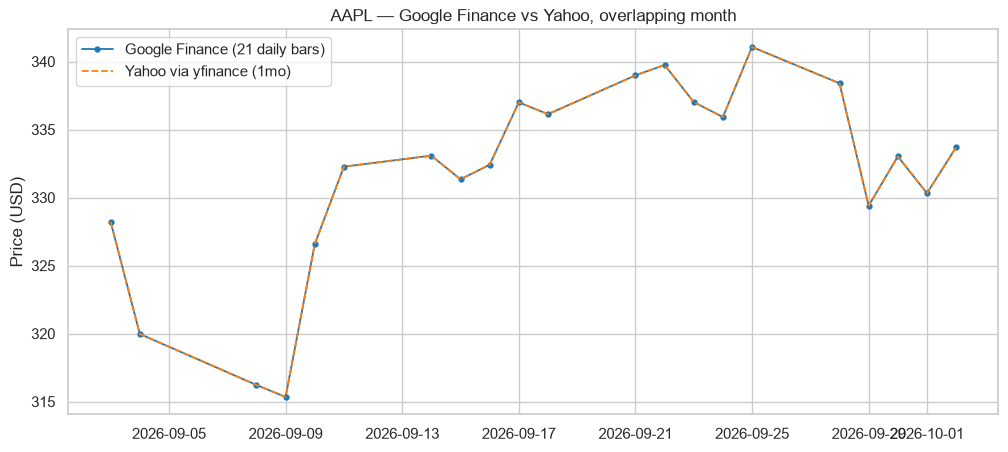

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gf.index, gf["Close"], marker="o", ms=3.5, lw=1.3, color="tab:blue", label="Google Finance (21 daily bars)")
ax.plot(compare.index, compare["yahoo"], lw=1.3, ls="--", color="tab:orange", label="Yahoo via yfinance (1mo)")

ax.set_title(f"{ticker} — Google Finance vs Yahoo, overlapping month")
ax.set_ylabel("Price (USD)")
ax.legend(loc="best")
plt.show()

## 5. What Google Finance does **not** give you here

Worth stating plainly, because this is the whole reason `stocklearn.data` stays the primary source:

| Wanted | Available from the static quote page? |
| --- | --- |
| Snapshot quote (price, change, prev close) | **Yes** |
| ~1 month of daily OHLCV, adjusted | **Yes** |
| Multi-year daily history for indicators/backtests | **No** — use `data.get_history()` |
| 52-week range, market cap, P/E, dividend yield | **No** — some appear in the page's *other* blobs, but undocumented and unstable; `fundamentals.py` is the supported path |
| Choosing the range (`period=`) | **No** — the window is fixed server-side |
| Intraday bars | **No** |
| A stable, documented API | **No** |

And the honest limit that follows from that last row: the markers we parse
(`AF_initDataCallback`, `data:`, ` sideChannel`) are **undocumented**. If Google reshapes the page, the
parser breaks loudly — a `ValueError`/`RuntimeError` with the reason, never a silently wrong price. That is
the designed failure mode, and it is why the parsing lives in small pure functions: when it does break, there
is exactly one place to fix.

## Recap

- Google Finance is a **second, independent price source**: a snapshot quote plus **~1 month** of adjusted daily bars.
- It is fetched with the **standard library only** — `urllib` for the HTML, a regex to find the `AF_initDataCallback` blobs, `json` to parse them.
- The quote row is a plain list; positions `[1]`, `[2]`, `[4]`, `[5]`, `[7]`, `[11]` carry ticker/exchange, name, currency, price/change/pct, previous close and the as-of timestamp.
- The **exchange is mandatory** (`AAPL:NASDAQ`); a missing suffix or wrong symbol raises `ValueError`, a network failure raises `RuntimeError`.
- Daily rows are `[open, close, high, low, timestamp, volume]`, already adjusted, so `Adj Close == Close` — and the two sources agree to the cent where they overlap.
- No multi-year history, no fundamentals, no `period=`: for those, keep using `stocklearn.data`.

**Try this:** run `google_history("KO", "NYSE")` and `google_history("NVDA", "NASDAQ")` — is the row count
always the same, and does the last date always match the quote's `as_of` date? Then open
`stocklearn/google_finance.py` and change `_find_quote_row` to try `QUOTE_KEYS` in a different order — do you
still get the same `Quote`? Finally, pick a ticker from another exchange (e.g. `"SAP:ETR"`, `"7203:TYO"`)
and see whether the same parser handles it; when it does not, note *which* check failed.